# Dataset Exploration

In [55]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from collections import Counter
import cv2
from typing import List, Tuple, Dict
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


project_root = Path().absolute().parent
image_dataset = project_root / 'attemptnumberfive' / 'data' / 'raw' / 'deepfashion' / 'original'
metadata_dataset = project_root / 'attemptnumberfive' / 'data' / 'raw' / 'deepfashion' / 'metadata'
synthetic_dataset = project_root / 'attemptnumberfive' / 'data' / 'raw' / 'deepfashion' / 'synthetic_degraded' / 'test'
scraped_dataset = project_root / 'attemptnumberfive' / 'data' / 'scraped'
src_root = project_root / 'attemptnumberfive'

sys.path.insert(0, str(src_root))

# import synthetic degradation implementation
from src.data.synthetic import (
    SyntheticDegradationPipeline,
    DegradationType,
    ConditionLevel,
    batch_generate_synthetic_data
)

## 1. Deepfashion Dataset Overview

In [2]:
inventory_file = metadata_dataset / 'dataset_inventory.json'
stats_file = metadata_dataset / 'dataset_stats.json'

with open(inventory_file, 'r') as f:
    inventory = json.load(f)

# Load stats
with open(stats_file, 'r') as f:
    stats = json.load(f)

image_list_file = metadata_dataset / 'image_list.csv'
df_images = pd.read_csv(image_list_file)

### 1.1 Image analysis

In [3]:
# summary about the dataset
print("Dataset Statistics:")
print(f"Total images: {stats.get('total_images', 0)}")
print(f"Valid images: {stats.get('valid_images', 0)}")
print(f"Invalid images: {stats.get('invalid_images', 0)}")
print(f"Total size: {stats.get('total_size_mb', 0)} MB")
print(f"Average size: {stats.get('avg_size_mb', 0)} MB")
print(f"Loaded {len(df_images):,} image records")
print("Sample image records:")
display(df_images.head())
print("Dimension Statistics:")
print("Width:")
print(df_images['width'].describe())
print("Height:")
print(df_images['height'].describe())
print("Aspect Ratio:")
print(df_images['aspect_ratio'].describe())

Dataset Statistics:
Total images: 289219
Valid images: 289219
Invalid images: 0
Total size: 2955.63 MB
Average size: 0.01 MB
Loaded 289,219 image records
Sample image records:


,path,absolute_path,filename,size_bytes,size_mb,width,height,aspect_ratio,mode,format,valid
0,1981_Graphic_Ringer_Tee\img_00000001.jpg,C:\Users\ionsphere\Downloads\ai course\capston...,img_00000001.jpg,9441,0.01,205,300,0.68,RGB,JPEG,True
1,1981_Graphic_Ringer_Tee\img_00000002.jpg,C:\Users\ionsphere\Downloads\ai course\capston...,img_00000002.jpg,9556,0.01,205,300,0.68,RGB,JPEG,True
2,1981_Graphic_Ringer_Tee\img_00000003.jpg,C:\Users\ionsphere\Downloads\ai course\capston...,img_00000003.jpg,7001,0.01,170,250,0.68,RGB,JPEG,True
3,1981_Graphic_Ringer_Tee\img_00000004.jpg,C:\Users\ionsphere\Downloads\ai course\capston...,img_00000004.jpg,8354,0.01,225,300,0.75,RGB,JPEG,True
4,1981_Graphic_Ringer_Tee\img_00000005.jpg,C:\Users\ionsphere\Downloads\ai course\capston...,img_00000005.jpg,8423,0.01,300,300,1.00,RGB,JPEG,True


Dimension Statistics:
Width:
count    289219.000000
mean        233.893800
std          46.961859
min          36.000000
25%         200.000000
50%         224.000000
75%         300.000000
max         301.000000
Name: width, dtype: float64
Height:
count    289219.000000
mean        289.019684
std          28.917577
min          48.000000
25%         300.000000
50%         300.000000
75%         300.000000
max         301.000000
Name: height, dtype: float64
Aspect Ratio:
count    289219.000000
mean          0.819861
std           0.204411
min           0.190000
25%           0.670000
50%           0.770000
75%           1.000000
max           5.000000
Name: aspect_ratio, dtype: float64


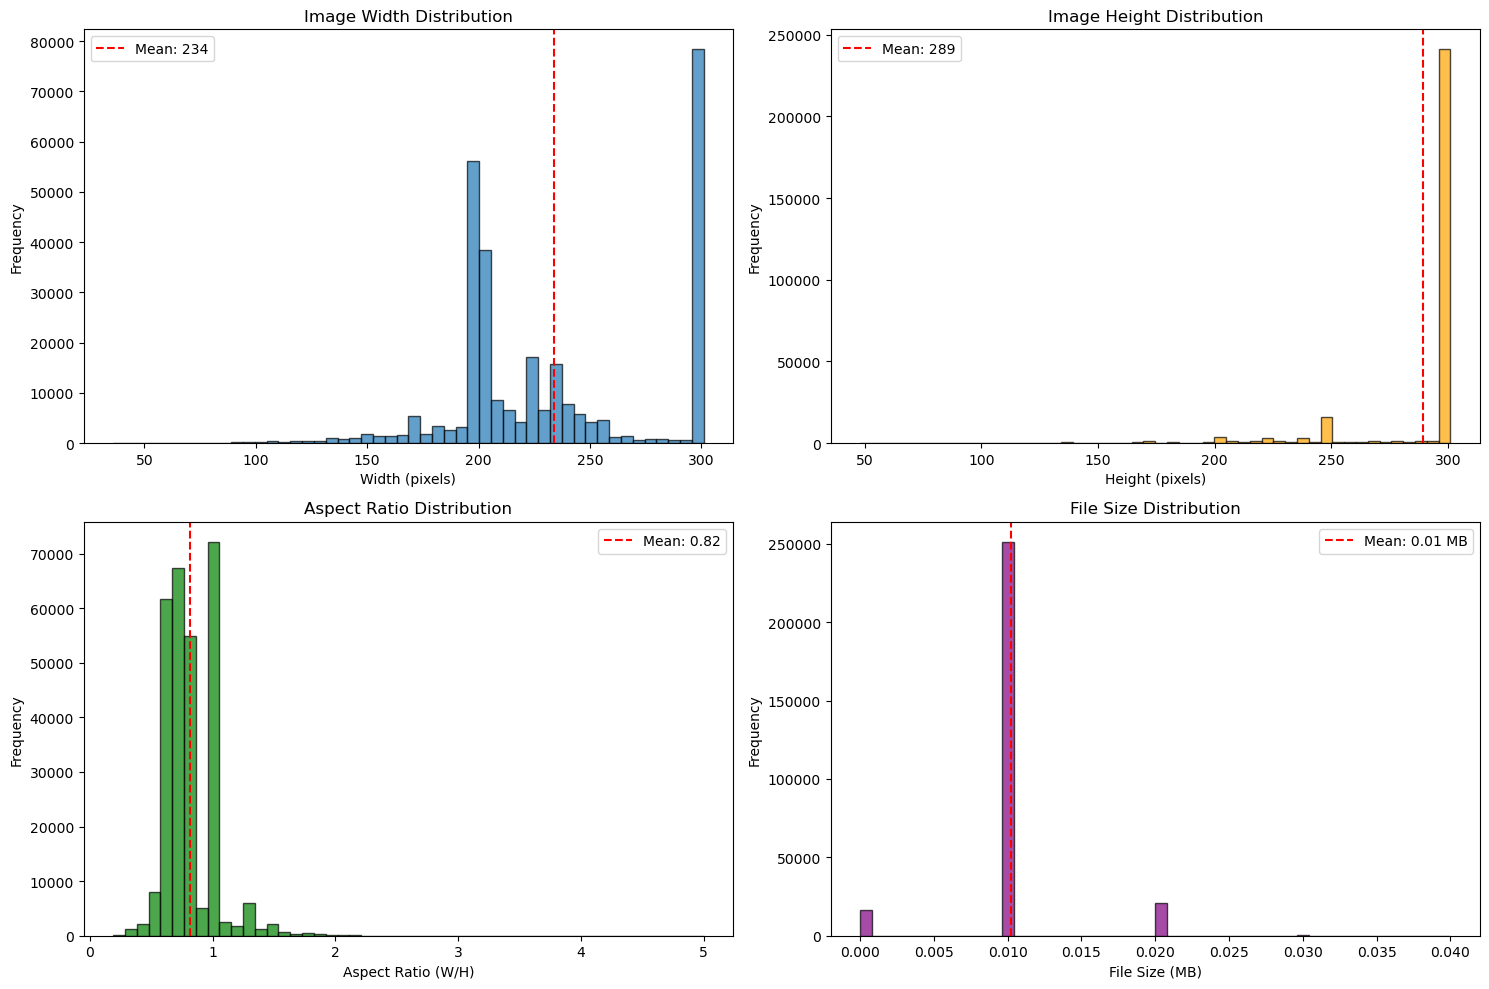

In [4]:
# dataset charts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

top_left, top_right, bottom_left, bottom_right = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

top_left.hist(df_images['width'], bins=50, edgecolor='black', alpha=0.7)
top_left.set_xlabel('Width (pixels)')
top_left.set_ylabel('Frequency')
top_left.set_title('Image Width Distribution')
top_left.axvline(df_images['width'].mean(), color='red', linestyle='--', label=f'Mean: {df_images["width"].mean():.0f}')
top_left.legend()

top_right.hist(df_images['height'], bins=50, edgecolor='black', alpha=0.7, color='orange')
top_right.set_xlabel('Height (pixels)')
top_right.set_ylabel('Frequency')
top_right.set_title('Image Height Distribution')
top_right.axvline(df_images['height'].mean(), color='red', linestyle='--', label=f'Mean: {df_images["height"].mean():.0f}')
top_right.legend()

bottom_left.hist(df_images['aspect_ratio'], bins=50, edgecolor='black', alpha=0.7, color='green')
bottom_left.set_xlabel('Aspect Ratio (W/H)')
bottom_left.set_ylabel('Frequency')
bottom_left.set_title('Aspect Ratio Distribution')
bottom_left.axvline(df_images['aspect_ratio'].mean(), color='red', linestyle='--', label=f'Mean: {df_images["aspect_ratio"].mean():.2f}')
bottom_left.legend()

bottom_right.hist(df_images['size_mb'], bins=50, edgecolor='black', alpha=0.7, color='purple')
bottom_right.set_xlabel('File Size (MB)')
bottom_right.set_ylabel('Frequency')
bottom_right.set_title('File Size Distribution')
bottom_right.axvline(df_images['size_mb'].mean(), color='red', linestyle='--',  label=f'Mean: {df_images["size_mb"].mean():.2f} MB')
bottom_right.legend()

plt.tight_layout()
plt.show()

### 1.2 Label analysis

Found 50 images with categories
Unique categories: 3
Category Distribution:
Category 1: 20 images
Category 2: 16 images
Category 3: 14 images


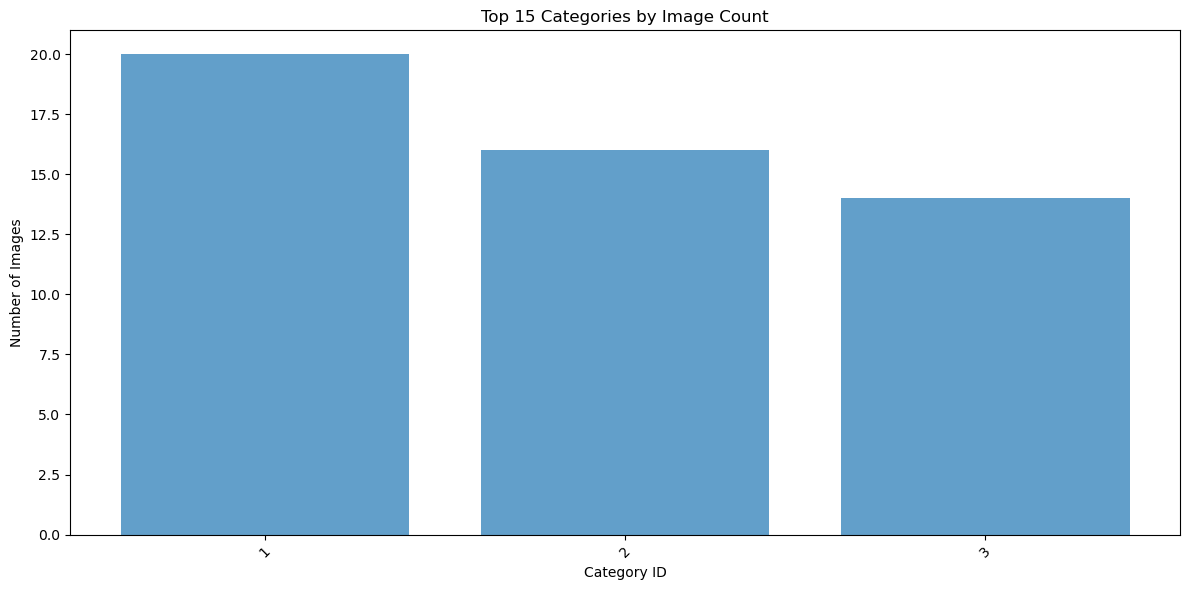

Found 2 attributes
Attribute Names:
1. image_name
2. attribute_labels
Most Common Attributes:
image_name: 3402 images
attribute_labels: 3346 images


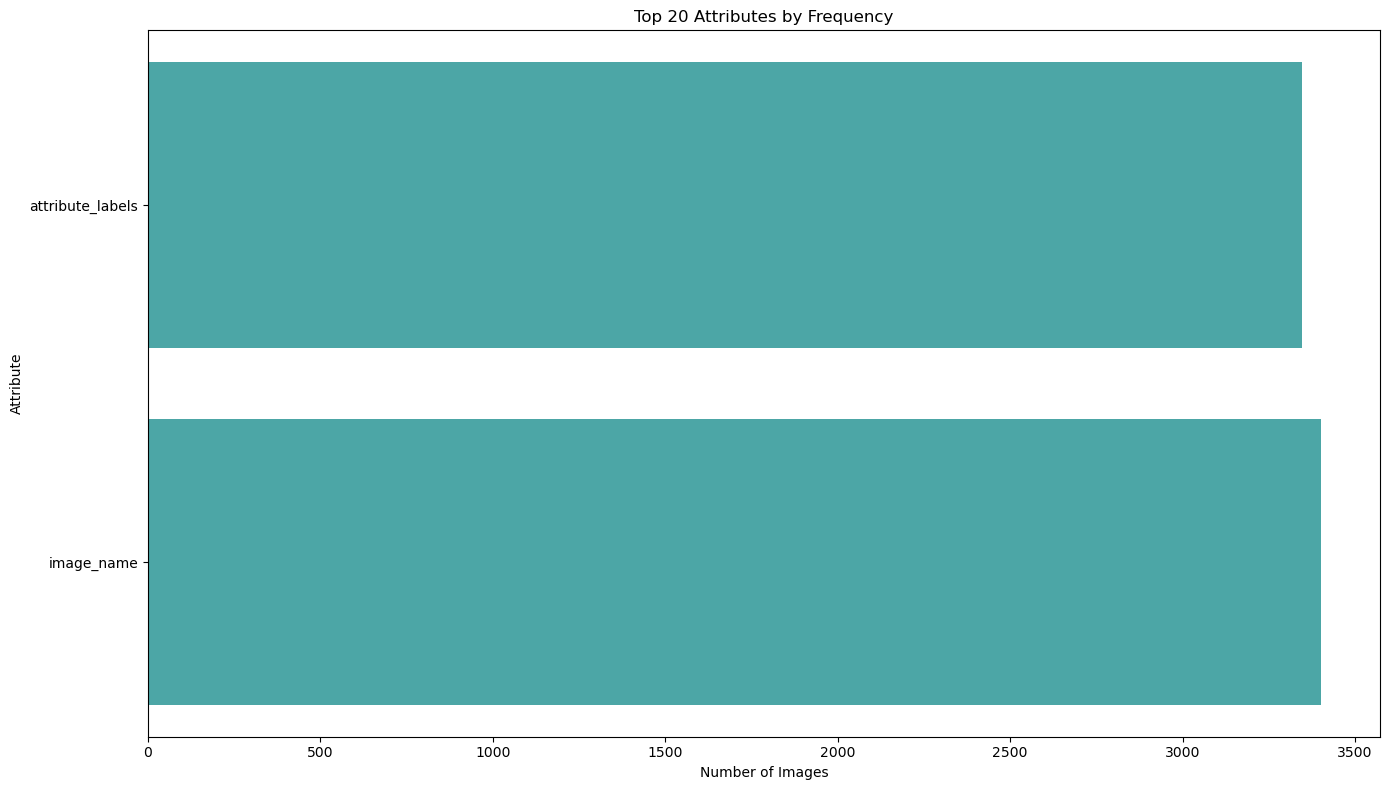

Images < 100px: 975
Images > 2000px: 0
Unusual aspect ratios (< 0.5 or > 2.0): 4734


In [5]:
category_file = image_dataset / 'Anno' / 'list_category_cloth.txt'
attr_file = image_dataset / 'Anno' / 'list_attr_img.txt'

categories = {}
category_counts = Counter()

with open(category_file, 'r') as f:
    lines = f.readlines()

for line in lines[2:]:
    parts = line.strip().split()
    if len(parts) >= 2:
        img_path = parts[0]
        category_id = parts[1]
        categories[img_path] = category_id
        category_counts[category_id] += 1

with open(attr_file, 'r') as f:
    lines = f.readlines()

if len(lines) > 2:
    attr_names_line = lines[1].strip()
    attr_names = attr_names_line.split()
    
    attr_counts = Counter()
    for line in lines[2:]:
        parts = line.strip().split()
        if len(parts) > 1:
            for i, val in enumerate(parts[1:]):
                if val == '1' and i < len(attr_names):
                    attr_counts[attr_names[i]] += 1


print(f"Found {len(categories)} images with categories")
print(f"Unique categories: {len(category_counts)}")
print("Category Distribution:")
for cat_id, count in category_counts.most_common(10):
    print(f"Category {cat_id}: {count} images")

top_categories = dict(category_counts.most_common(15))

plt.figure(figsize=(12, 6))
plt.bar(range(len(top_categories)), list(top_categories.values()), tick_label=list(top_categories.keys()), alpha=0.7)
plt.xlabel('Category ID')
plt.ylabel('Number of Images')
plt.title('Top 15 Categories by Image Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Found {len(attr_names)} attributes")
print(f"Attribute Names:")
for i, attr in enumerate(attr_names, 1):
    print(f"{i}. {attr}")

print(f"Most Common Attributes:")
for attr, count in attr_counts.most_common(10):
    print(f"{attr}: {count} images")

top_attrs = dict(attr_counts.most_common(20))

plt.figure(figsize=(14, 8))
plt.barh(range(len(top_attrs)), list(top_attrs.values()), tick_label=list(top_attrs.keys()), alpha=0.7, color='teal')
plt.xlabel('Number of Images')
plt.ylabel('Attribute')
plt.title('Top 20 Attributes by Frequency')
plt.tight_layout()
plt.show()

small_images = df_images[(df_images['width'] < 100) | (df_images['height'] < 100)]
print(f"Images < 100px: {len(small_images)}")
large_images = df_images[(df_images['width'] > 2000) | (df_images['height'] > 2000)]
print(f"Images > 2000px: {len(large_images)}")
unusual_ar = df_images[(df_images['aspect_ratio'] < 0.5) | (df_images['aspect_ratio'] > 2.0)]
print(f"Unusual aspect ratios (< 0.5 or > 2.0): {len(unusual_ar)}")

### 1.3. Train/Val/Test Split Analysis

Data Splits:
Train: 209222 (72.3%)
Val: 40000 (13.8%)
Test: 40000 (13.8%)
Total: 289222


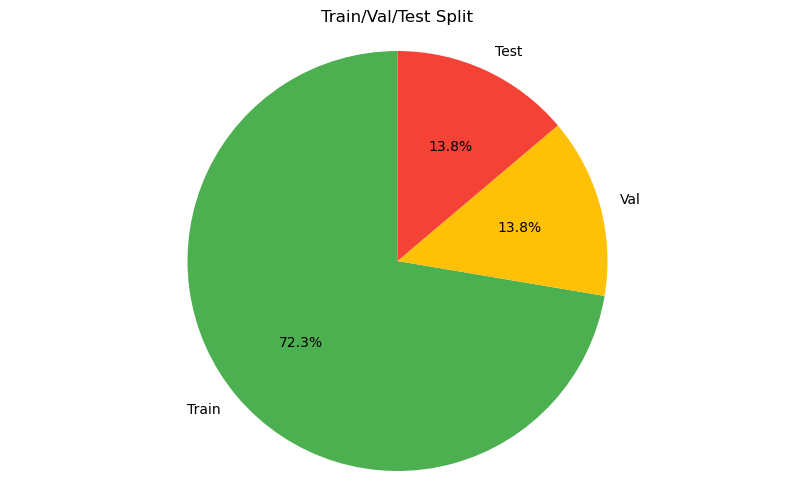

In [6]:
eval_file = image_dataset / 'Eval' / 'list_eval_partition.txt'
splits = {'train': [], 'val': [], 'test': []}

with open(eval_file, 'r') as f:
    lines = f.readlines()

for line in lines[2:]:
    parts = line.strip().split()
    if len(parts) >= 2:
        img_path = parts[0]
        split_type = parts[1]
        if split_type in splits:
            splits[split_type].append(img_path)

total = sum(len(v) for v in splits.values())

print("Data Splits:")
print(f"Train: {len(splits['train'])} ({len(splits['train'])/total*100:.1f}%)")
print(f"Val: {len(splits['val'])} ({len(splits['val'])/total*100:.1f}%)")
print(f"Test: {len(splits['test'])} ({len(splits['test'])/total*100:.1f}%)")
print(f"Total: {total}")

plt.figure(figsize=(10, 6))
split_sizes = [len(splits['train']), len(splits['val']), len(splits['test'])]
split_labels = ['Train', 'Val', 'Test']
colors = ['#4CAF50', '#FFC107', '#F44336']

plt.pie(split_sizes, labels=split_labels, autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Train/Val/Test Split')
plt.axis('equal')
plt.show()

### 1.4 Enhance dataset with synthetic degradation

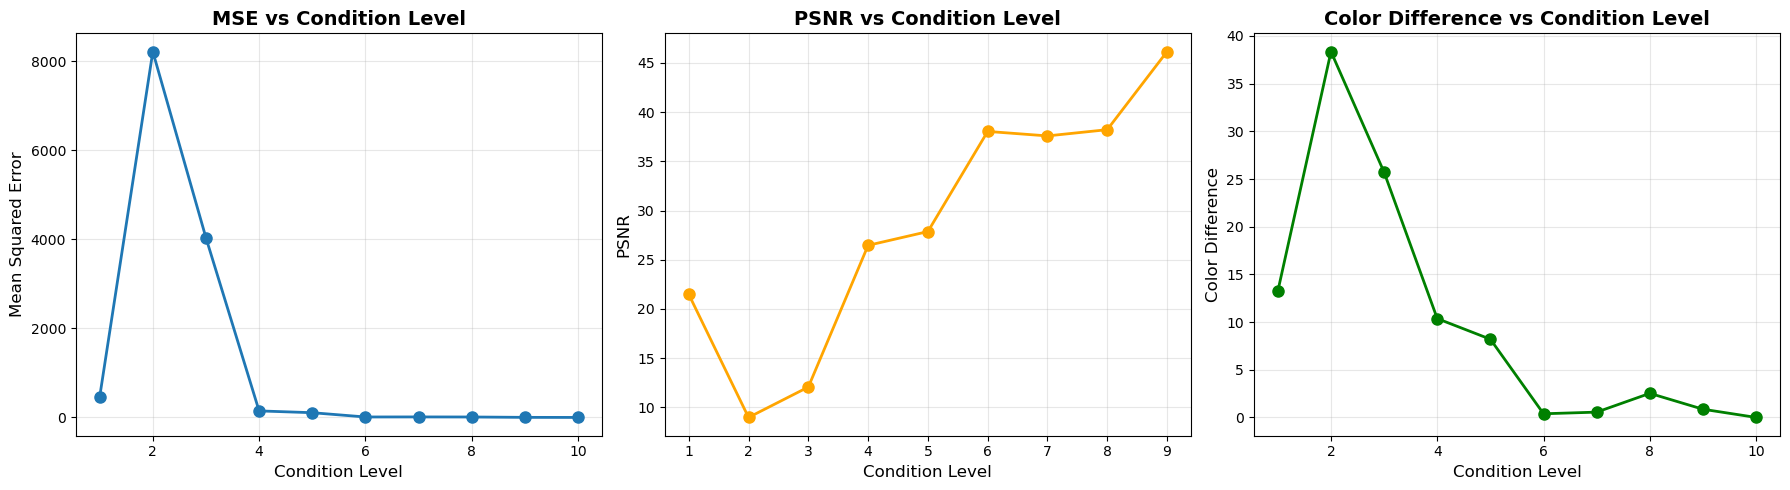

Quality Metrics Legend
Higher condition levels should have:
  • Lower MSE (less difference from original)
  • Higher PSNR (better quality)
  • Lower Color Difference (less fading)


In [10]:
pipeline = SyntheticDegradationPipeline(seed=42)

def calculate_image_metrics(img1: np.ndarray, img2: np.ndarray) -> Dict:
    # compare image content
    mse = np.mean((img1.astype(float) - img2.astype(float)) ** 2)
    
    # Peak Signal-to-Noise Ratio
    if mse == 0:
        psnr = float('inf')
    else:
        psnr = 20 * np.log10(255.0 / np.sqrt(mse))
    
    # Color difference
    color_diff = np.mean(np.abs(img1.mean(axis=(0,1)) - img2.mean(axis=(0,1))))
    
    return {
        'mse': mse,
        'psnr': psnr,
        'color_difference': color_diff
    }

conditions = range(1, 11)
metrics_by_condition = []

image_extensions = ['.jpg', '.jpeg', '.png']
for ext in image_extensions:
    sample_images = list(image_dataset.rglob(f'*{ext}'))
    if sample_images:
        sample_image_path = sample_images[0]
        break

sample_img = cv2.cvtColor(cv2.imread(str(sample_image_path)), cv2.COLOR_BGR2RGB)

for condition in conditions:
    degraded_img, _ = pipeline.apply_degradation(
        sample_img.copy(),
        condition_level=condition,
        intensity=1.0
    )
    
    metrics = calculate_image_metrics(sample_img, degraded_img)
    metrics['condition'] = condition
    metrics_by_condition.append(metrics)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

conditions_list = [m['condition'] for m in metrics_by_condition]
mse_list = [m['mse'] for m in metrics_by_condition]
psnr_list = [m['psnr'] for m in metrics_by_condition]
color_diff_list = [m['color_difference'] for m in metrics_by_condition]

axes[0].plot(conditions_list, mse_list, 'o-', linewidth=2, markersize=8)
axes[0].set_xlabel('Condition Level', fontsize=12)
axes[0].set_ylabel('Mean Squared Error', fontsize=12)
axes[0].set_title('MSE vs Condition Level', fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(conditions_list, psnr_list, 'o-', linewidth=2, markersize=8, color='orange')
axes[1].set_xlabel('Condition Level', fontsize=12)
axes[1].set_ylabel('PSNR', fontsize=12)
axes[1].set_title('PSNR vs Condition Level', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

axes[2].plot(conditions_list, color_diff_list, 'o-', linewidth=2, markersize=8, color='green')
axes[2].set_xlabel('Condition Level', fontsize=12)
axes[2].set_ylabel('Color Difference', fontsize=12)
axes[2].set_title('Color Difference vs Condition Level', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Quality Metrics Legend")
print("Higher condition levels should have:")
print("  • Lower MSE (less difference from original)")
print("  • Higher PSNR (better quality)")
print("  • Lower Color Difference (less fading)")

## 2. Used Market Price Dataset Analysis

In [19]:
platforms = [p.name for p in scraped_dataset.iterdir() if p.is_dir() and p.name not in ['.ipynb_checkpoints', 'cleaned', 'debug_thredup']]
def load_platform_data(platform: str) -> pd.DataFrame:
    platform_dir = scraped_dataset / platform
    items = []
    json_files = list(platform_dir.glob('*.json'))
    for json_file in json_files:
        try:
            with open(json_file, 'r', encoding='utf-8') as f:
                data = json.load(f)
                items.append(data)
        except Exception as e:
            print(f"Warning: Failed to load {json_file}: {e}")
    
    batch_dir = platform_dir / 'batches'
    if batch_dir.exists():
        batch_files = list(batch_dir.glob('*.json'))
        for batch_file in batch_files:
            try:
                with open(batch_file, 'r', encoding='utf-8') as f:
                    data = json.load(f)
                    if 'items' in data:
                        items.extend(data['items'])
            except Exception as e:
                print(f"Warning: Failed to load {batch_file}: {e}")
    
    if not items:
        return pd.DataFrame()
    
    df = pd.DataFrame(items)
    return df


dfs = {}
for platform in platforms:
    df = load_platform_data(platform)
    if not df.empty:
        dfs[platform] = df

if dfs:
    df_all = pd.concat(dfs.values(), ignore_index=True)
else:
    df_all = pd.DataFrame()

df_all = df_all[df_all['price'] > 0].copy()

### 2.1 Dataset shape

In [16]:
print(f"Found platforms: {platforms}")
print(f"Total items loaded: {len(df_all)}")
print("Dataset shape:", df_all.shape)
print("Columns:", list(df_all.columns))
print("First few rows:")
display(df_all.head())

print("Data types:")
display(df_all.dtypes)
print("Missing values:")
display(df_all.isnull().sum())
print("Basic statistics:")
display(df_all.describe())

Found platforms: ['depop', 'poshmark', 'thredup', 'unified']
Total items loaded: 3761
Dataset shape: (3761, 20)
Columns: ['platform', 'item_id', 'url', 'title', 'price', 'currency', 'brand', 'condition', 'description', 'category', 'size', 'color', 'image_urls', 'seller_id', 'seller_rating', 'num_likes', 'num_comments', 'listing_date', 'scraped_at', 'raw_data']
First few rows:


,platform,item_id,url,title,price,currency,brand,condition,description,category,size,color,image_urls,seller_id,seller_rating,num_likes,num_comments,listing_date,scraped_at,raw_data
0,depop,3mii-bright-pink-sequin-mini-dress-30e0,https://www.depop.com/products/3mii-bright-pin...,bright pink sequin mini dress // hand sewn siz...,12.46,USD,None,Good,bright pink sequin mini dress // hand sewn siz...,None,XS,Pink,[https://media-photos.depop.com/b1/34876458/34...,None,None,None,None,None,2026-03-04T16:30:08.784339,{'product_data': {'name': 'bright pink sequin ...
1,depop,4uthriftz-nike-basketball-shorts-size-small-7b31,https://www.depop.com/products/4uthriftz-nike-...,Nike Basketball shorts\n-size small\n-excellen...,10.15,USD,Nike,Good,Nike Basketball shorts\n-size small\n-excellen...,None,S,None,[https://media-photos.depop.com/b1/378125569/3...,None,None,None,None,None,2026-03-04T16:56:28.733717,{'product_data': {'name': 'Nike Basketball sho...
2,depop,abbeeeeeeeeeee-forever-21-light-wash-wide-e6c9,https://www.depop.com/products/abbeeeeeeeeeee-...,Forever 21 light wash wide leg jeans Size 28 #...,7.32,USD,Forever 21,Like New,Forever 21 light wash wide leg jeans Size 28 #...,None,28,None,[https://media-photos.depop.com/b1/436176592/3...,None,None,None,None,None,2026-03-04T16:37:15.586057,{'product_data': {'name': 'Forever 21 light wa...
3,depop,adrocks_archive-vintage-y2k-levis-505-regular-...,https://www.depop.com/products/adrocks_archive...,Vintage Y2K Levi’s 505 regular fit jeans in ni...,20.64,USD,Levi's,Good Condition,Vintage Y2K Levi’s 505 regular fit jeans in ni...,None,30,None,[https://media-photos.depop.com/b1/52853238/34...,None,None,None,None,None,2026-03-04T16:38:22.104667,{'product_data': {'name': 'Vintage Y2K Levi’s ...
4,depop,ale12330-levis-559-relaxed-straight-fit-622c,https://www.depop.com/products/ale12330-levis-...,Levi’s 559 relaxed straight fit jeans in a blu...,7.00,USD,Levi's,Used,Levi’s 559 relaxed straight fit jeans in a blu...,None,30,Blue,[https://media-photos.depop.com/b1/48942168/34...,None,None,None,None,None,2026-03-04T16:37:25.138006,{'product_data': {'name': 'Levi’s 559 relaxed ...


Data types:


platform          object
item_id           object
url               object
title             object
price            float64
currency          object
brand             object
condition         object
description       object
category          object
size              object
color             object
image_urls        object
seller_id         object
seller_rating     object
num_likes         object
num_comments      object
listing_date      object
scraped_at        object
raw_data          object
dtype: object

Missing values:


platform            0
item_id             0
url                 0
title               0
price               0
currency            0
brand             343
condition          77
description         0
category          317
size               79
color             155
image_urls          0
seller_id        3761
seller_rating    3761
num_likes        3761
num_comments     3761
listing_date     3761
scraped_at          0
raw_data            0
dtype: int64

Basic statistics:


,price
count,3761.000000
mean,28.735778
std,26.535983
min,0.000000
25%,15.000000
50%,22.000000
75%,35.000000
max,383.000000


### 2.2 Dataset analysis

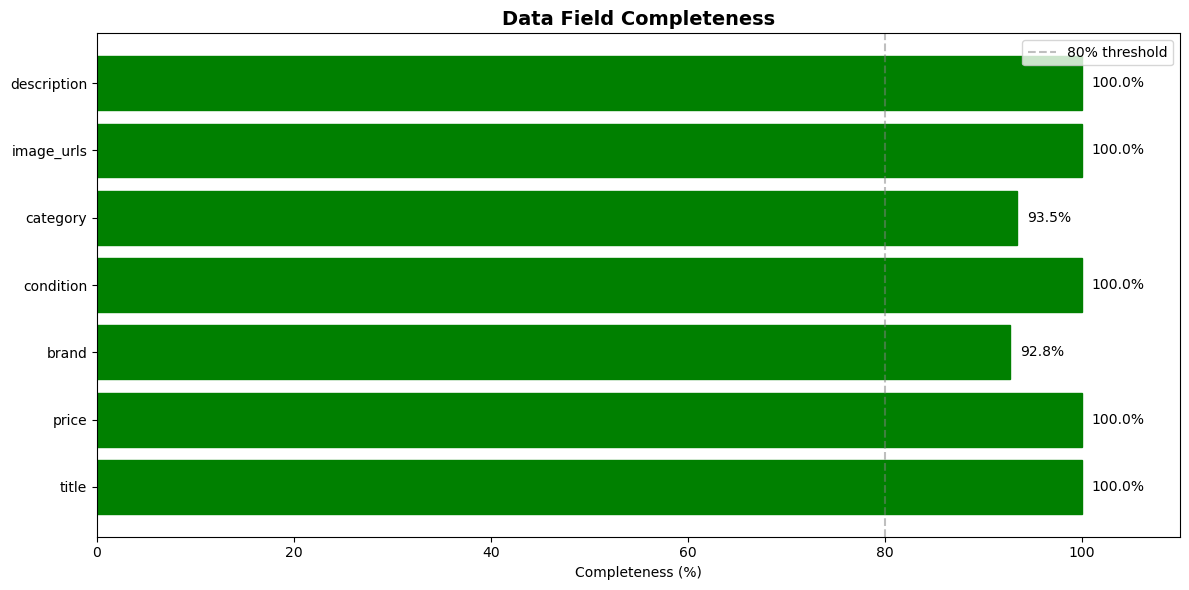

In [31]:
key_fields = ['title', 'price', 'brand', 'condition', 'category', 'image_urls', 'description']
completeness = []

for field in key_fields:
    if field in df_all.columns:
        if field == 'image_urls':
            pct = (df_all[field].apply(lambda x: isinstance(x, list) and len(x) > 0).sum() / len(df_all)) * 100
        else:
            pct = (df_all[field].notna().sum() / len(df_all)) * 100
        completeness.append(pct)
    else:
        completeness.append(0)

plt.figure(figsize=(12, 6))
bars = plt.barh(key_fields, completeness)

for i, (bar, val) in enumerate(zip(bars, completeness)):
    if val > 80:
        bar.set_color('green')
    elif val > 50:
        bar.set_color('orange')
    else:
        bar.set_color('red')
    
    plt.text(val + 1, i, f'{val:.1f}%', va='center')

plt.xlabel('Completeness (%)')
plt.title('Data Field Completeness', fontsize=14, fontweight='bold')
plt.xlim(0, 110)
plt.axvline(80, color='gray', linestyle='--', alpha=0.5, label='80% threshold')
plt.legend()
plt.tight_layout()
plt.show()

### 2.3 Price/platform analysis

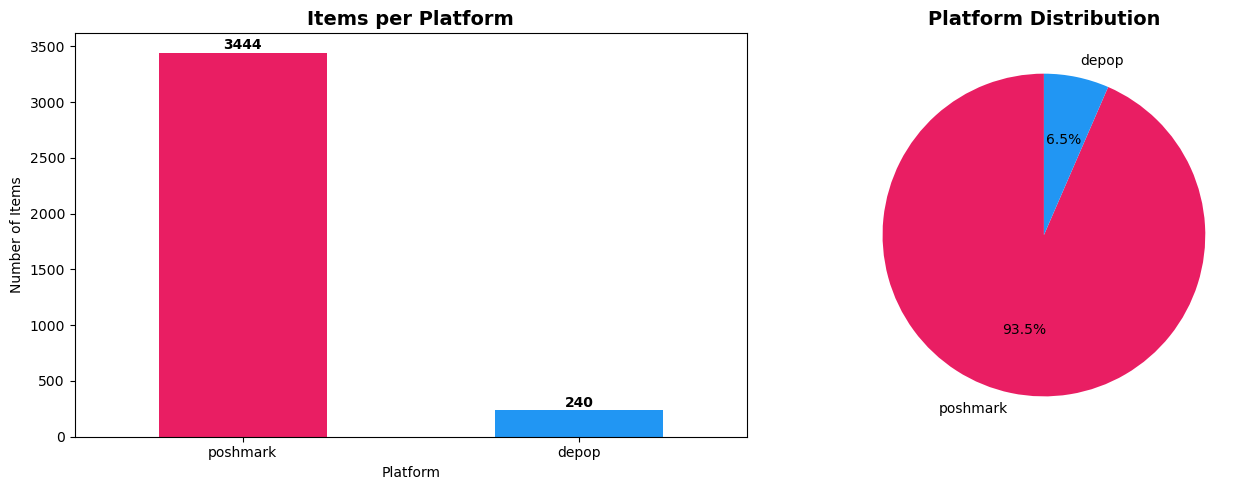

In [24]:
platform_counts = df_all['platform'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
platform_counts.plot(kind='bar', ax=ax1, color=['#E91E63', '#2196F3', '#4CAF50'])
ax1.set_title('Items per Platform', fontsize=14, fontweight='bold')
ax1.set_xlabel('Platform')
ax1.set_ylabel('Number of Items')
ax1.tick_params(axis='x', rotation=0)

for i, v in enumerate(platform_counts):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

platform_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90, colors=['#E91E63', '#2196F3', '#4CAF50'])
ax2.set_title('Platform Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

### 2.4 Price analysis

Price statistics (all platforms):
count    3684.00000
mean       29.33639
std        26.48123
min         2.80000
25%        15.00000
50%        23.00000
75%        35.00000
max       383.00000
Name: price, dtype: float64
Price range: $2.80 - $383.00
Median price: $23.00


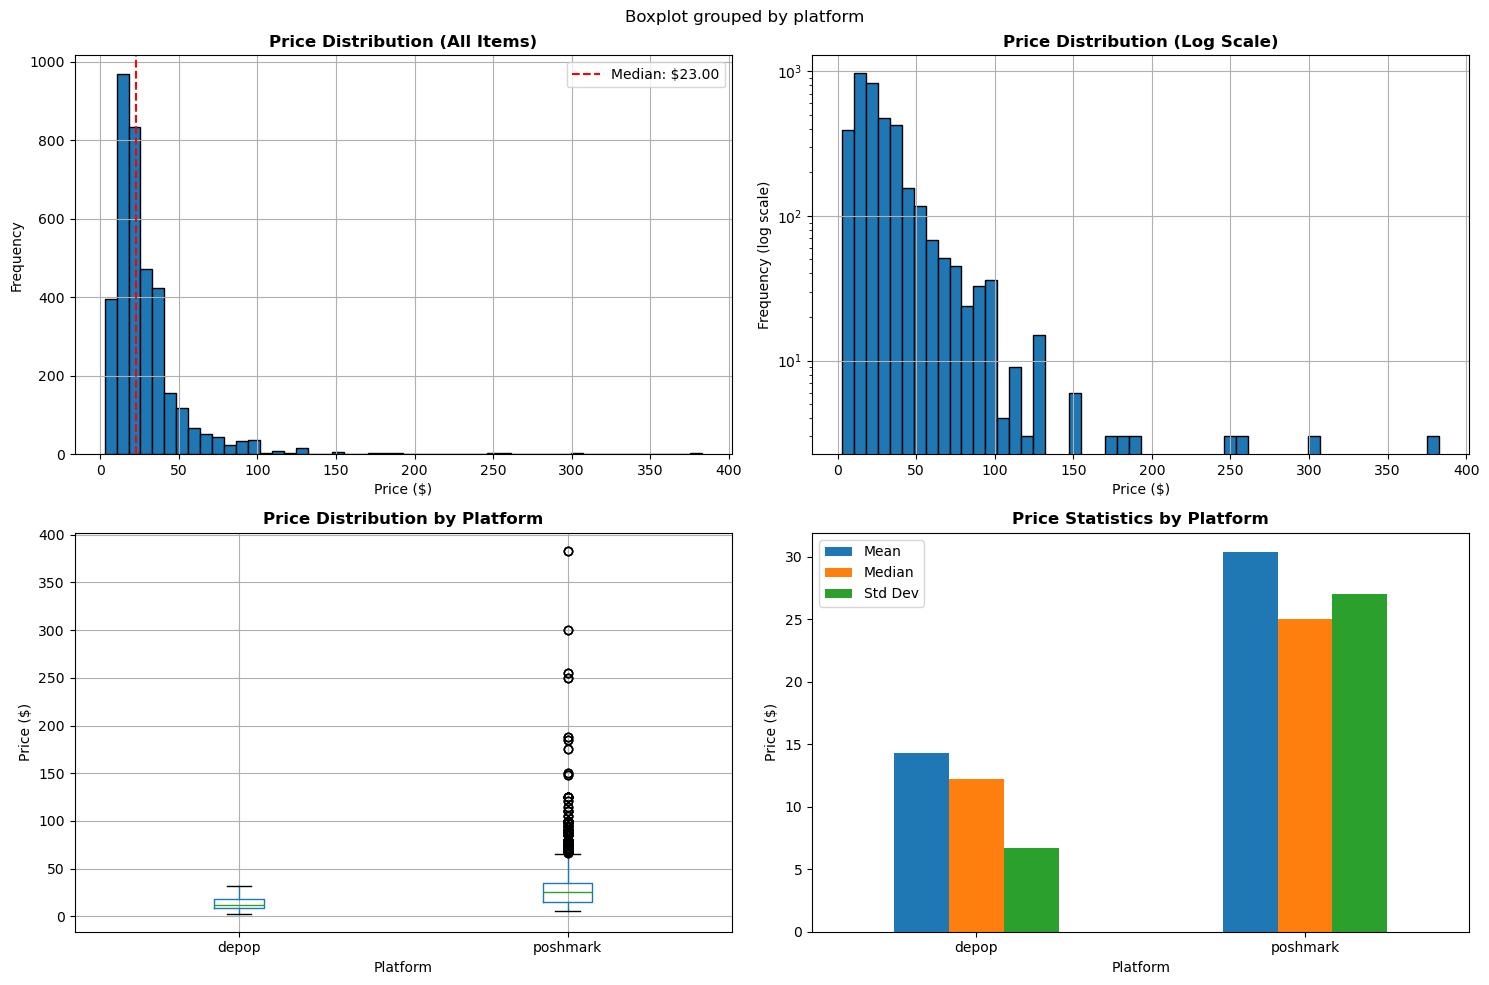


Price statistics by platform:
               mean  median        std
platform                              
depop     14.317750   12.25   6.672774
poshmark  30.382985   25.00  27.022736


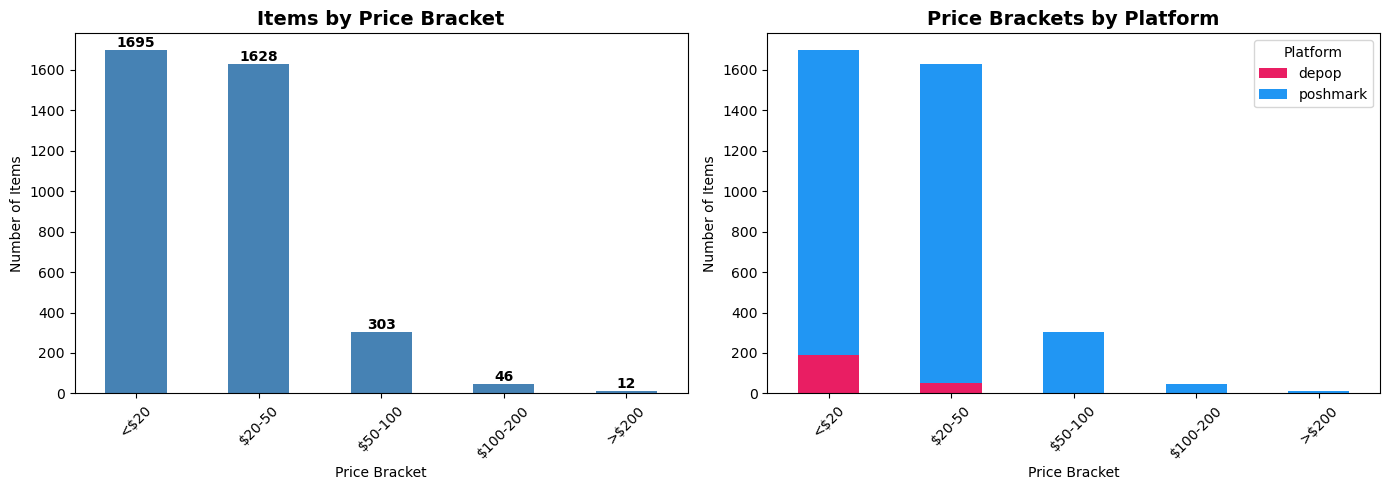

Price bracket distribution:
price_bracket
<$20        1695
$20-50      1628
$50-100      303
$100-200      46
>$200         12
Name: count, dtype: int64
Price bracket by platform:
platform       depop  poshmark
price_bracket                 
<$20             190      1505
$20-50            50      1578
$50-100            0       303
$100-200           0        46
>$200              0        12


In [25]:
print("Price statistics (all platforms):")
print(df_all['price'].describe())
print(f"Price range: ${df_all['price'].min():.2f} - ${df_all['price'].max():.2f}")
print(f"Median price: ${df_all['price'].median():.2f}")

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
top_left, top_right, bottom_left, bottom_right = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]
df_all['price'].hist(bins=50, ax=axes[0, 0], edgecolor='black')
top_left.set_title('Price Distribution (All Items)', fontsize=12, fontweight='bold')
top_left.set_xlabel('Price ($)')
top_left.set_ylabel('Frequency')
top_left.axvline(df_all['price'].median(), color='red', linestyle='--', label=f"Median: ${df_all['price'].median():.2f}")
top_left.legend()

# Log scale distribution
df_all['price'].hist(bins=50, ax=top_right, edgecolor='black', log=True)
top_right.set_title('Price Distribution (Log Scale)', fontsize=12, fontweight='bold')
top_right.set_xlabel('Price ($)')
top_right.set_ylabel('Frequency (log scale)')

# Price by platform
df_all.boxplot(column='price', by='platform', ax=bottom_left)
bottom_left.set_title('Price Distribution by Platform', fontsize=12, fontweight='bold')
bottom_left.set_xlabel('Platform')
bottom_left.set_ylabel('Price ($)')
plt.sca(bottom_left)
plt.xticks(rotation=0)

# Price statistics by platform
price_by_platform = df_all.groupby('platform')['price'].agg(['mean', 'median', 'std'])
price_by_platform.plot(kind='bar', ax=axes[1, 1])
bottom_right.set_title('Price Statistics by Platform', fontsize=12, fontweight='bold')
bottom_right.set_xlabel('Platform')
bottom_right.set_ylabel('Price ($)')
bottom_right.legend(['Mean', 'Median', 'Std Dev'])
bottom_right.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print("\nPrice statistics by platform:")
print(price_by_platform)

bins = [0, 20, 50, 100, 200, float('inf')]
labels = ['<$20', '$20-50', '$50-100', '$100-200', '>$200']
df_all['price_bracket'] = pd.cut(df_all['price'], bins=bins, labels=labels)

bracket_counts = df_all['price_bracket'].value_counts().sort_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
bracket_counts.plot(kind='bar', ax=ax1, color='steelblue')
ax1.set_title('Items by Price Bracket', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price Bracket')
ax1.set_ylabel('Number of Items')
ax1.tick_params(axis='x', rotation=45)

for i, v in enumerate(bracket_counts):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

bracket_platform = pd.crosstab(df_all['price_bracket'], df_all['platform'])
bracket_platform.plot(kind='bar', stacked=True, ax=ax2, color=['#E91E63', '#2196F3', '#4CAF50'])
ax2.set_title('Price Brackets by Platform', fontsize=14, fontweight='bold')
ax2.set_xlabel('Price Bracket')
ax2.set_ylabel('Number of Items')
ax2.tick_params(axis='x', rotation=45)
ax2.legend(title='Platform')

plt.tight_layout()
plt.show()

print("Price bracket distribution:")
print(bracket_counts)
print("Price bracket by platform:")
print(bracket_platform)

### 2.5 Brand analysis

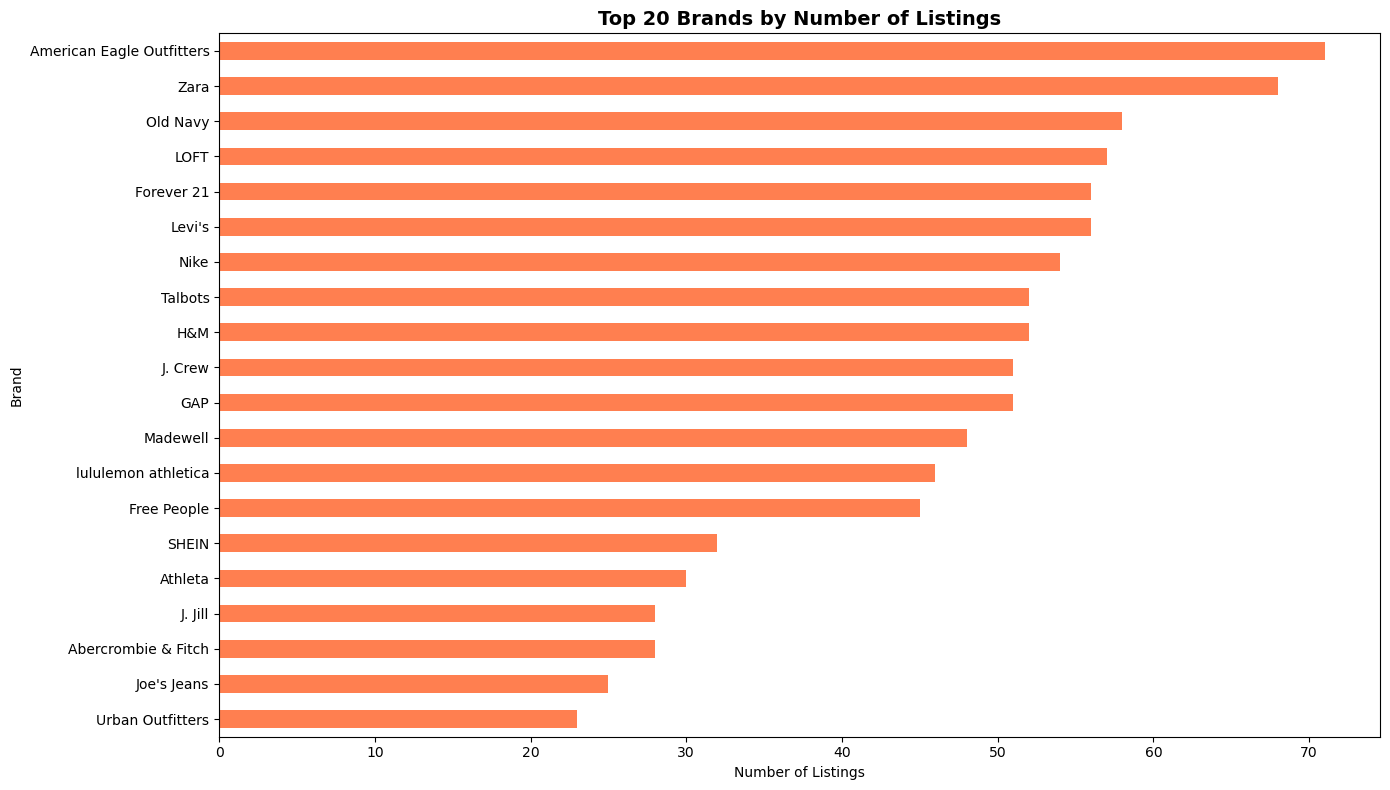

Total unique brands: 549
Items with brand information: 3418 (92.8%)


<Figure size 1400x800 with 0 Axes>

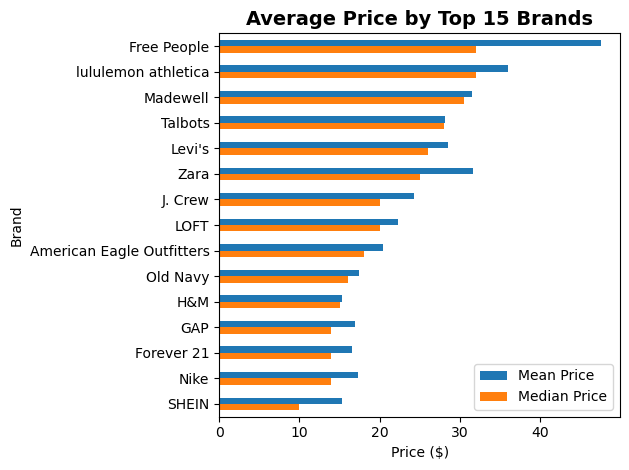


Price statistics for top brands:
                                mean  median  count
brand                                              
Free People                47.577778    32.0     45
lululemon athletica        35.978261    32.0     46
Madewell                   31.500000    30.5     48
Talbots                    28.192308    28.0     52
Levi's                     28.572143    26.0     56
Zara                       31.623529    25.0     68
J. Crew                    24.294118    20.0     51
LOFT                       22.263158    20.0     57
American Eagle Outfitters  20.373239    18.0     71
Old Navy                   17.412069    16.0     58
H&M                        15.253846    15.0     52
GAP                        16.882353    14.0     51
Forever 21                 16.548929    14.0     56
Nike                       17.316667    14.0     54
SHEIN                      15.365625    10.0     32


In [27]:
df_brand = df_all[df_all['brand'].notna()].copy()

top_brands = df_brand['brand'].value_counts().head(20)

plt.figure(figsize=(14, 8))
top_brands.plot(kind='barh', color='coral')
plt.title('Top 20 Brands by Number of Listings', fontsize=14, fontweight='bold')
plt.xlabel('Number of Listings')
plt.ylabel('Brand')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total unique brands: {df_brand['brand'].nunique()}")
print(f"Items with brand information: {len(df_brand)} ({len(df_brand)/len(df_all)*100:.1f}%)")

# Average price by top brands
top_brands_list = df_brand['brand'].value_counts().head(15).index
df_top_brands = df_brand[df_brand['brand'].isin(top_brands_list)]

brand_price_stats = df_top_brands.groupby('brand')['price'].agg(['mean', 'median', 'count']).sort_values('median', ascending=False)

plt.figure(figsize=(14, 8))
brand_price_stats[['mean', 'median']].plot(kind='barh')
plt.title('Average Price by Top 15 Brands', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Brand')
plt.legend(['Mean Price', 'Median Price'])
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\nPrice statistics for top brands:")
print(brand_price_stats)

### 2.6 Condition analysis

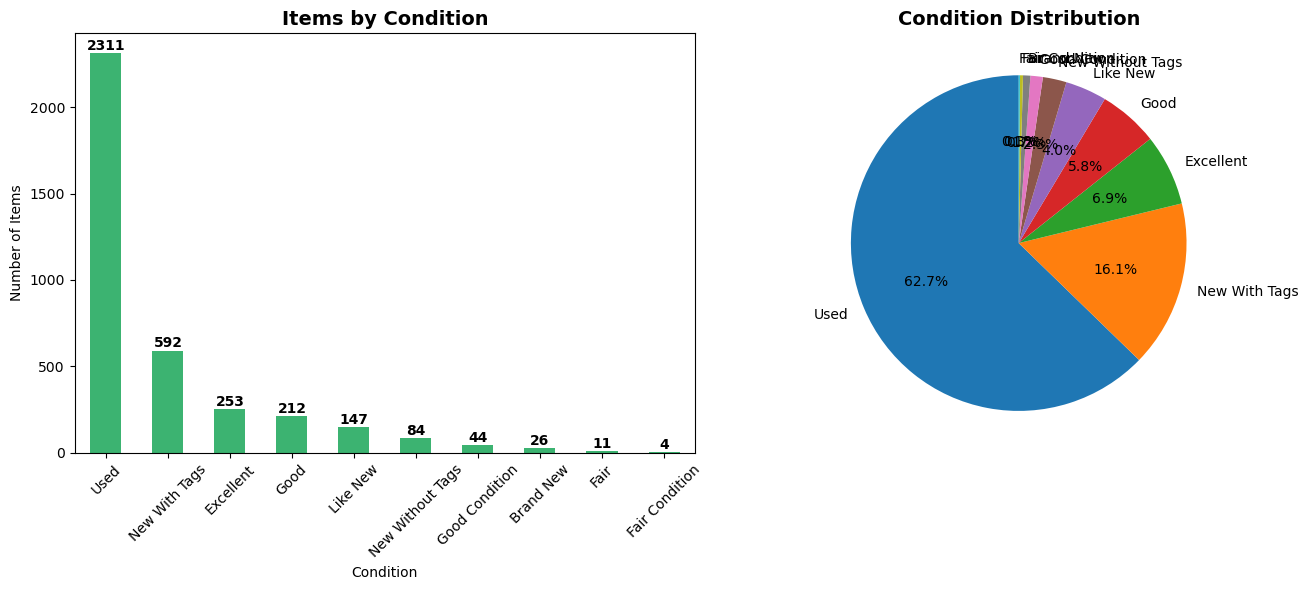

Condition distribution:
condition
Used                2311
New With Tags        592
Excellent            253
Good                 212
Like New             147
New Without Tags      84
Good Condition        44
Brand New             26
Fair                  11
Fair Condition         4
Name: count, dtype: int64
Items with condition info: 3684 (100.0%)


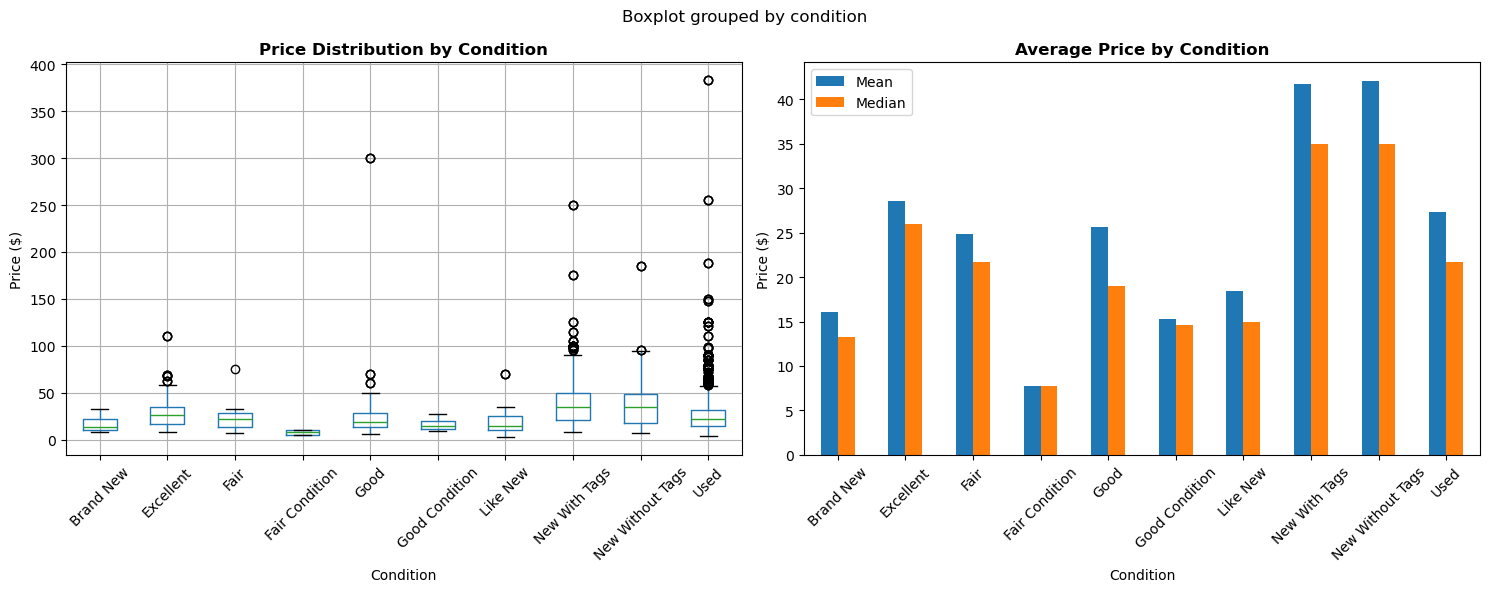

Price statistics by condition:
Axes(0.53931,0.236873;0.45069x0.654238)


In [29]:
df_condition = df_all[df_all['condition'].notna()].copy()

condition_counts = df_condition['condition'].value_counts()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
condition_counts.plot(kind='bar', ax=ax1, color='mediumseagreen')
ax1.set_title('Items by Condition', fontsize=14, fontweight='bold')
ax1.set_xlabel('Condition')
ax1.set_ylabel('Number of Items')
ax1.tick_params(axis='x', rotation=45)

for i, v in enumerate(condition_counts):
    ax1.text(i, v + 1, str(v), ha='center', va='bottom', fontweight='bold')

condition_counts.plot(kind='pie', ax=ax2, autopct='%1.1f%%', startangle=90)
ax2.set_title('Condition Distribution', fontsize=14, fontweight='bold')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

print("Condition distribution:")
print(condition_counts)
print(f"Items with condition info: {len(df_condition)} ({len(df_condition)/len(df_all)*100:.1f}%)")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
df_condition.boxplot(column='price', by='condition', ax=ax1)
ax1.set_title('Price Distribution by Condition', fontsize=12, fontweight='bold')
ax1.set_xlabel('Condition')
ax1.set_ylabel('Price ($)')
plt.sca(ax1)
plt.xticks(rotation=45)

cond_price_stats = df_condition.groupby('condition')['price'].agg(['mean', 'median']).plot(kind='bar', ax=ax2)
ax2.set_title('Average Price by Condition', fontsize=12, fontweight='bold')
ax2.set_xlabel('Condition')
ax2.set_ylabel('Price ($)')
ax2.legend(['Mean', 'Median'])
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Price statistics by condition:")
print(cond_price_stats)

### 2.7 Category analysis

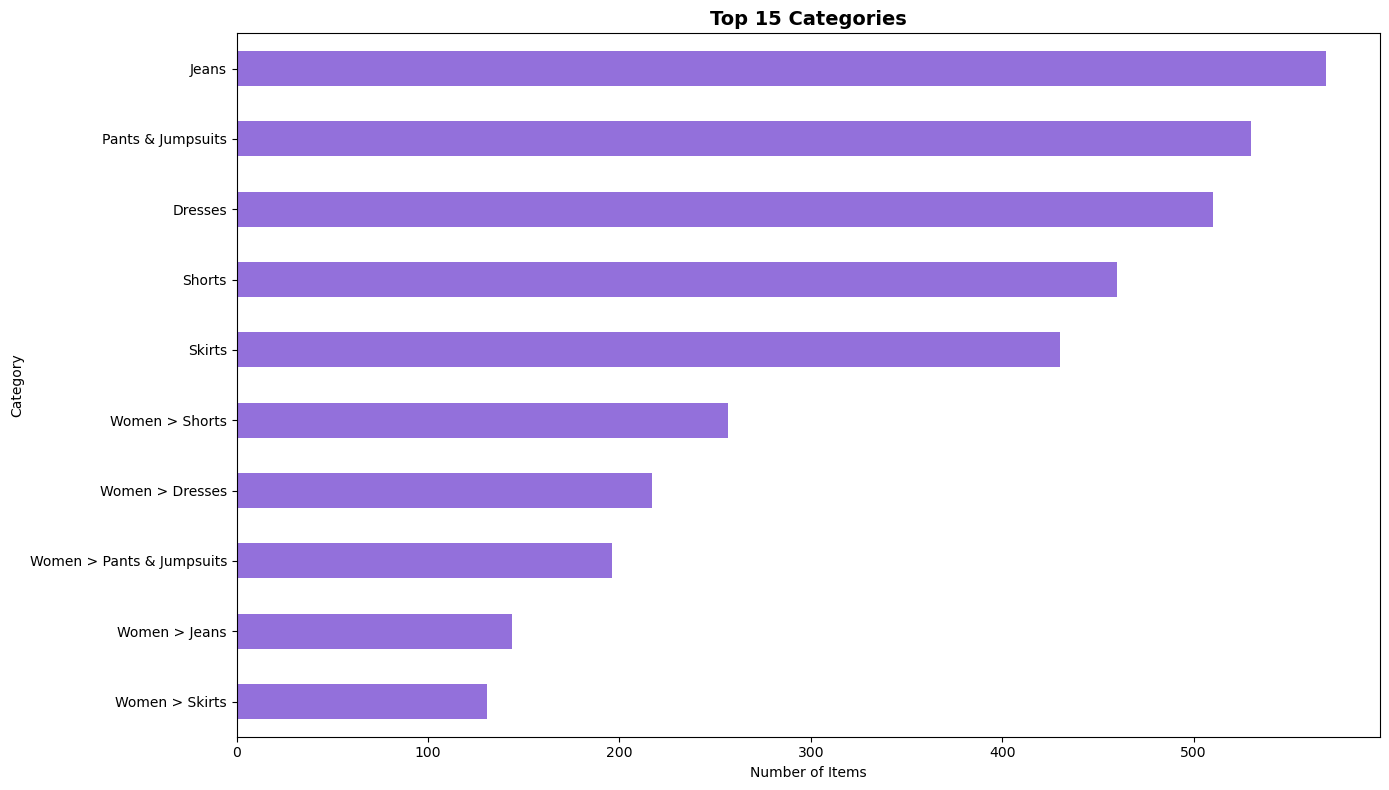

Total unique categories: 10
Items with category info: 3444 (93.5%)


In [30]:
df_category = df_all[df_all['category'].notna()].copy()

category_counts = df_category['category'].value_counts().head(15)

plt.figure(figsize=(14, 8))
category_counts.plot(kind='barh', color='mediumpurple')
plt.title('Top 15 Categories', fontsize=14, fontweight='bold')
plt.xlabel('Number of Items')
plt.ylabel('Category')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(f"Total unique categories: {df_category['category'].nunique()}")
print(f"Items with category info: {len(df_category)} ({len(df_category)/len(df_all)*100:.1f}%)")

### 2.8 Base model

In [57]:
#LogisticRegression
rename = {
    '<$20': 1,
    '$20-50': 2,
    '$50-100': 3,
    '$100-200': 4,
    '>$200': 5,
}
df_model = df_all[['brand', 'condition', 'category', 'color', 'price_bracket']]
df_model['price_bucket'] = df_model['price_bracket'].apply(lambda r: int(rename[r])).astype(int)

X = df_model[['brand', 'condition', 'category', 'color']]
y = df_model['price_bucket']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)

p = Pipeline(steps=[('cat', OneHotEncoder(handle_unknown='ignore')), ('lr', LogisticRegression())]).fit(X_train, y_train)
y_pred = p.predict(X_test)
score = accuracy_score(y_test, y_pred)
score

C:\Users\ionsphere\AppData\Local\Temp\ipykernel_20840\772366199.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_model['price_bucket'] = df_model['price_bracket'].apply(lambda r: int(rename[r])).astype(int)


0.7882736156351792